In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) 

In [2]:
df = pd.read_csv('group_26_train.csv')

In [3]:
print("Dataset Shape:", df.shape)

df.head(5)

Dataset Shape: (100000, 35)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source2,2018-03-30 17:32:46,40.810566,-73.256042,NaN,NaN,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,NaN,29.77,10.0,NNW,13.8,0.01,Overcast,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2
1,Source1,2022-07-27 13:42:00,45.358867,-122.762271,45.341362,-122.768971,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,90.0,29.78,10.0,NNE,3.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
2,Source1,2022-06-06 13:00:30,41.233610,-95.954493,41.242050,-95.953603,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,76.0,28.67,10.0,VAR,3.0,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,2021-09-07 21:50:00,34.039947,-117.505855,34.037156,-117.505860,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,77.0,28.89,10.0,WSW,5.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2
4,Source2,2019-05-23 20:52:35,47.230240,-122.448868,NaN,NaN,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,63.0,29.53,10.0,W,8.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,3


In [4]:
print("List of all features:")
print(df.columns.tolist())

List of all features:
['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y']


In [5]:
print("\nDetailed feature information:")
print(df.dtypes)


Detailed feature information:
f1         str
f2         str
f3     float64
f4     float64
f5     float64
f6     float64
f7     float64
f8         str
f9         str
f10        str
f11        str
f12        str
f13        str
f14    float64
f15    float64
f16    float64
f17    float64
f18        str
f19    float64
f20    float64
f21        str
f22       bool
f23       bool
f24       bool
f25       bool
f26       bool
f27       bool
f28       bool
f29       bool
f30       bool
f31        str
f32        str
f33        str
f34        str
y        int64
dtype: object


In [6]:
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)

str        14
float64    11
bool        9
int64       1
Name: count, dtype: int64


In [7]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)

Numeric columns: 11
['f3', 'f4', 'f5', 'f6', 'f7', 'f14', 'f15', 'f16', 'f17', 'f19', 'f20']

Categorical columns: 14
['f1', 'f2', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'f31', 'f32', 'f33', 'f34']

Boolean columns: 9
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30']


In [8]:
for feature in df.columns:
    if df[feature].dtype in ['bool', 'str']:
        display(df[feature].value_counts())
    else:
        pass


f1
Source1    55744
Source2    42981
Source3     1275
Name: count, dtype: int64

f2
2021-02-16 06:43:35    4
2021-01-26 16:16:13    4
2021-02-04 13:00:00    3
2022-01-08 10:34:30    3
2020-09-15 13:29:30    3
                      ..
2021-02-09 16:47:40    1
2022-01-12 11:14:31    1
2021-04-02 19:09:53    1
2020-12-28 14:01:00    1
2018-09-18 10:23:23    1
Name: count, Length: 99407, dtype: int64

f8
I-95 N              1059
I-95 S               938
I-5 N                872
I-10 W               726
I-5 S                687
                    ... 
Eva Mae Dr             1
 N 12th St             1
 State Route 295       1
N Francis Ave          1
Throgs Neck Brg        1
Name: count, Length: 32428, dtype: int64

f9
Miami               2323
Houston             2224
Los Angeles         2055
Dallas              1745
Charlotte           1740
                    ... 
Rancho Dominguez       1
Stinnett               1
Jarrell                1
South Rockwood         1
Sandwich               1
Name: count, Length: 6406, dtype: int64

f10
Los Angeles      6815
Miami-Dade       3150
Orange           3147
Harris           2387
Dallas           2104
                 ... 
Early               1
Hopewell City       1
Navarro             1
Sac                 1
Hutchinson          1
Name: count, Length: 1303, dtype: int64

...

f30
False    100000
Name: count, dtype: int64

f31
Day      68859
Night    30828
Name: count, dtype: int64

f32
Day      73568
Night    26119
Name: count, dtype: int64

f33
Day      78677
Night    21010
Name: count, dtype: int64

f34
Day      82524
Night    17163
Name: count, dtype: int64

In [9]:

df['f2'] = pd.to_datetime(df['f2'], format='mixed', errors='coerce')

df['hour'] = df['f2'].dt.hour
df['dayofweek'] = df['f2'].dt.dayofweek
df['month'] = df['f2'].dt.month
df['year'] = df['f2'].dt.year

df['dayofweek'] = df['dayofweek'].astype('str')
df['month'] = df['month'].astype('str')


display(df[['f2', 'year', 'month', 'dayofweek', 'hour']].head())

df = df.drop(columns=['f2'])



,f2,year,month,dayofweek,hour
0,2018-03-30 17:32:46,2018,3,4,17
1,2022-07-27 13:42:00,2022,7,2,13
2,2022-06-06 13:00:30,2022,6,0,13
3,2021-09-07 21:50:00,2021,9,1,21
4,2019-05-23 20:52:35,2019,5,3,20


In [10]:
df.head(5)

,f1,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,Source2,40.810566,-73.256042,NaN,NaN,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,NaN,29.77,10.0,NNW,13.8,0.01,Overcast,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2,17,4,3,2018
1,Source1,45.358867,-122.762271,45.341362,-122.768971,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,90.0,29.78,10.0,NNE,3.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2,13,2,7,2022
2,Source1,41.233610,-95.954493,41.242050,-95.953603,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,76.0,28.67,10.0,VAR,3.0,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2,13,0,6,2022
3,Source1,34.039947,-117.505855,34.037156,-117.505860,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,77.0,28.89,10.0,WSW,5.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2,21,1,9,2021
4,Source2,47.230240,-122.448868,NaN,NaN,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,63.0,29.53,10.0,W,8.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,3,20,3,5,2019


In [11]:
day_night_cols = ['f31','f32', 'f33', 'f34']

for col in day_night_cols:
    df[col] = df[col].map({'Day': False, 'Night': True}).astype(bool)


In [12]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)

Numeric columns: 13
['f3', 'f4', 'f5', 'f6', 'f7', 'f14', 'f15', 'f16', 'f17', 'f19', 'f20', 'hour', 'year']

Categorical columns: 11
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']

Boolean columns: 13
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,count,percent
y,,
1,860,0.86
2,79560,79.56
3,16910,16.91
4,2670,2.67


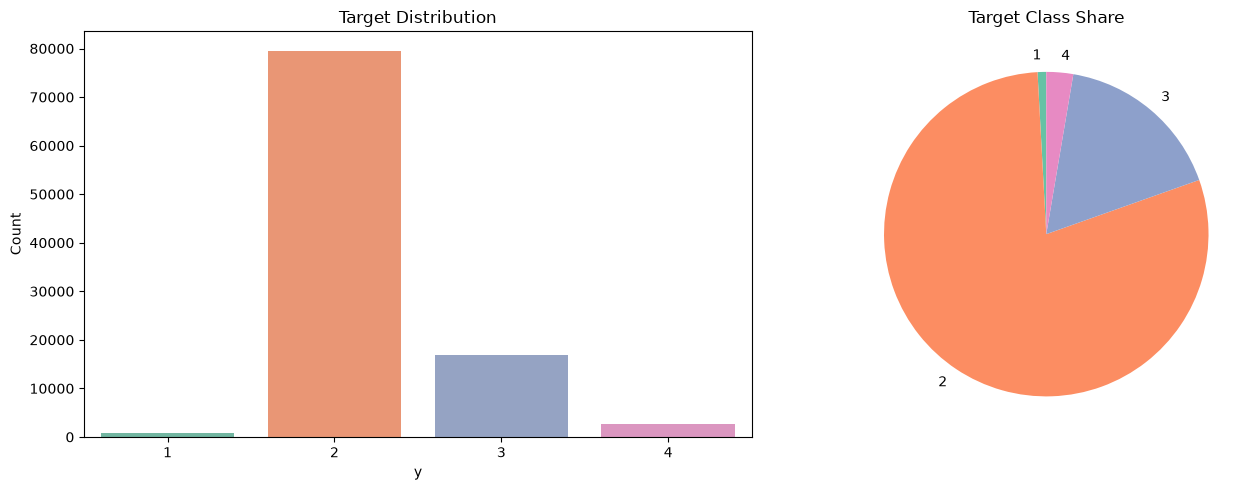

In [13]:
#important y
target_counts = df['y'].value_counts().sort_index()
target_percent = df['y'].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    'count': target_counts,
    'percent': target_percent
}))

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.countplot(data=df, x='y', ax=axes[0], palette='Set2')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Count')

axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    startangle=90,
    colors=sns.color_palette('Set2')
)

axes[1].set_title('Target Class Share')

plt.tight_layout()
plt.show()


Mutual Information Scores (Numerical vs y):
year    0.045894
f6      0.035666
f4      0.035264
f7      0.028625
f5      0.025043
f3      0.024425
f16     0.010404
f17     0.003779
f15     0.003417
f19     0.003193
hour    0.001894
f14     0.001057
f20     0.000000
dtype: float64


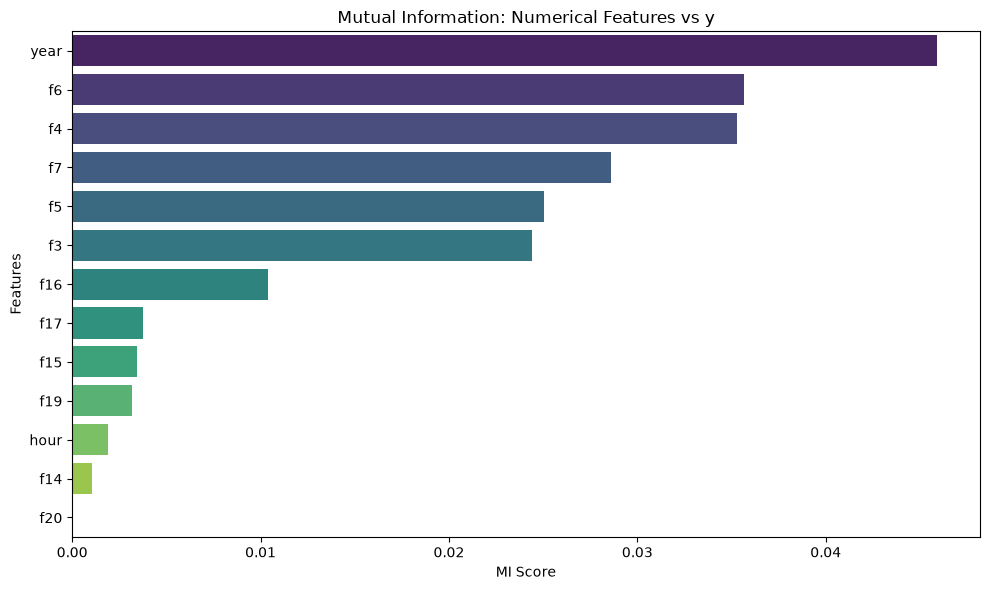

In [14]:
if 'numeric_cols' in locals() and 'y' in df.columns:
    # Data cleaning for MI
    cols_to_use = ['y'] + numeric_cols
    df_mi = df[cols_to_use].dropna()

    if df_mi['y'].nunique() >= 2:
        X_clean = df_mi[numeric_cols]
        y_clean = df_mi['y'].astype(int)

        mi_scores = mutual_info_classif(X_clean, y_clean, random_state=42)
        mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Numerical vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(numeric_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Numerical Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient data: Target 'y' has less than 2 unique classes after dropping NaNs.")
else:
    print("Missing 'numeric_cols' or target 'y' in DataFrame.")


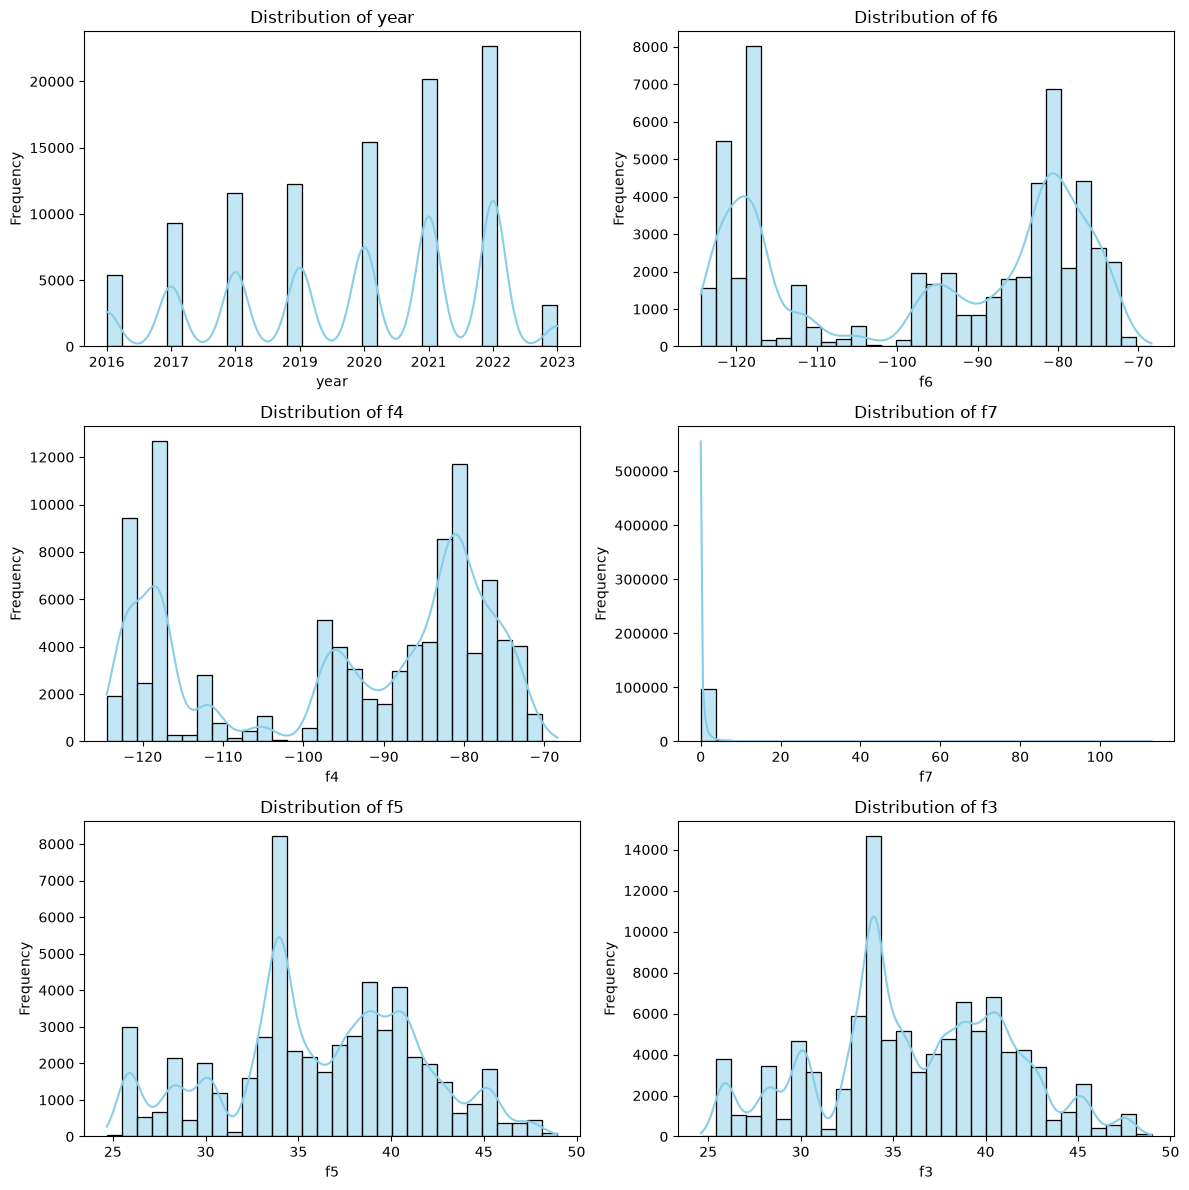

In [15]:
top_6_features = ['year','f6', 'f4', 'f7', 'f5', 'f3']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
axes = axes.flatten()  

for i, feature in enumerate(top_6_features):
    ax = axes[i]
    sns.histplot(df[feature].dropna(), kde=True, bins=30, color='skyblue', ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

if len(top_6_features) < len(axes):
    for j in range(len(top_6_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Categorical Feature Importance (MI or Gain Ratio):
  Feature    Score      Method  Cardinality
       f1 0.095415 Mutual Info            3
    month 0.010223 Mutual Info           12
       f8 0.008992  Gain Ratio        32428
      f12 0.008825  Gain Ratio        36879
      f10 0.008063  Gain Ratio         1303
      f21 0.007939  Gain Ratio           80
      f13 0.007746  Gain Ratio         1616
      f11 0.007425  Gain Ratio           49
       f9 0.006988  Gain Ratio         6406
dayofweek 0.003905 Mutual Info            7
      f18 0.003444  Gain Ratio           24


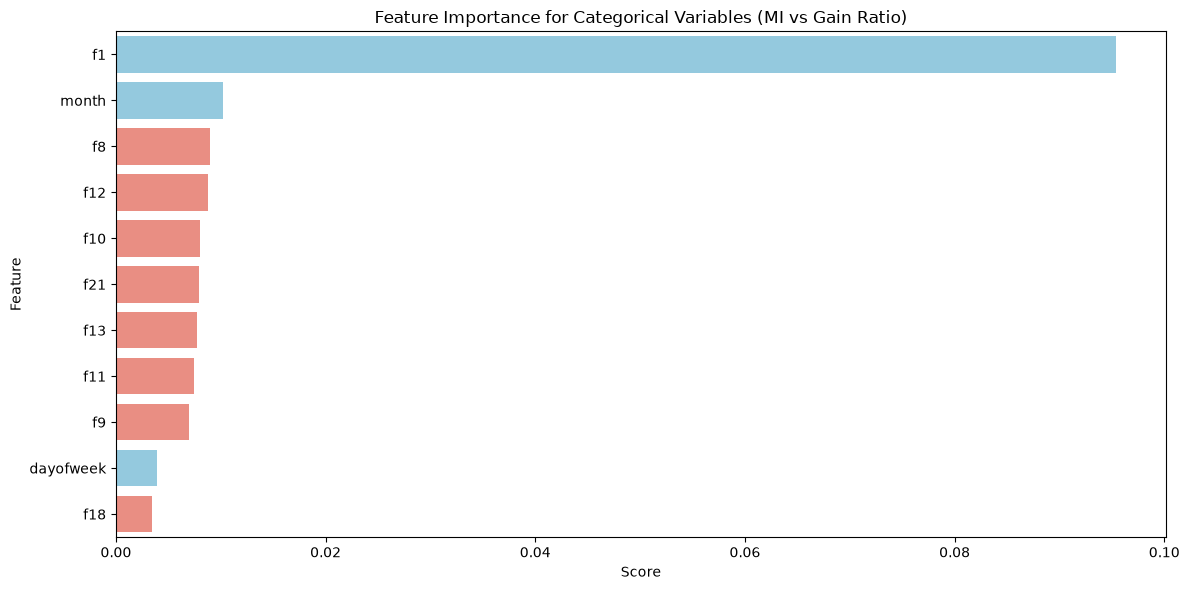

In [16]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

HIGH_CARD_THRESHOLD = 20   


if 'categorical_cols' in locals() and 'y' in df.columns:
    df_clean = df[['y'] + categorical_cols].dropna(subset=['y'])
    
    if df_clean['y'].nunique() >= 2:
        
        df_encoded = pd.DataFrame()
        for col in categorical_cols:
            df_encoded[col] = df_clean[col].astype('category').cat.codes
        
        X_cat = df_encoded
        y_cat = df_clean['y'].astype(int)
        
        def gain_ratio(X, y, col):
            mi = mutual_info_classif(X[[col]], y, random_state=42)[0]
            
            probs = X[col].value_counts(normalize=True)
            ent = -np.sum(probs * np.log2(probs + 1e-9))
            
            return mi / ent if ent > 0 else 0
        
        scores = []
        
        for col in categorical_cols:
            unique_count = df_clean[col].nunique()
            
            if unique_count > HIGH_CARD_THRESHOLD:
                gr_score = gain_ratio(X_cat, y_cat, col)
                scores.append((col, gr_score, 'Gain Ratio', unique_count))
            else:
                mi_score = mutual_info_classif(X_cat[[col]], y_cat, random_state=42)[0]
                scores.append((col, mi_score, 'Mutual Info', unique_count))
        

        results_df = pd.DataFrame(scores, columns=['Feature', 'Score', 'Method', 'Cardinality'])
        results_df = results_df.sort_values('Score', ascending=False)
        
        print("Categorical Feature Importance (MI or Gain Ratio):")
        print(results_df.to_string(index=False))
        
        plt.figure(figsize=(12, max(6, len(categorical_cols) * 0.4)))
        
        color_map = {'Mutual Info': 'skyblue', 'Gain Ratio': 'salmon'}
        colors = [color_map[m] for m in results_df['Method']]
        
        sns.barplot(x='Score', y='Feature', data=results_df, palette=colors)
        
        plt.title('Feature Importance for Categorical Variables (MI vs Gain Ratio)')
        plt.xlabel('Score')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    
    else:
        print("Target 'y' must have at least 2 classes after removing missing values.")
else:
    print("Missing 'categorical_cols' or target 'y' in DataFrame.")

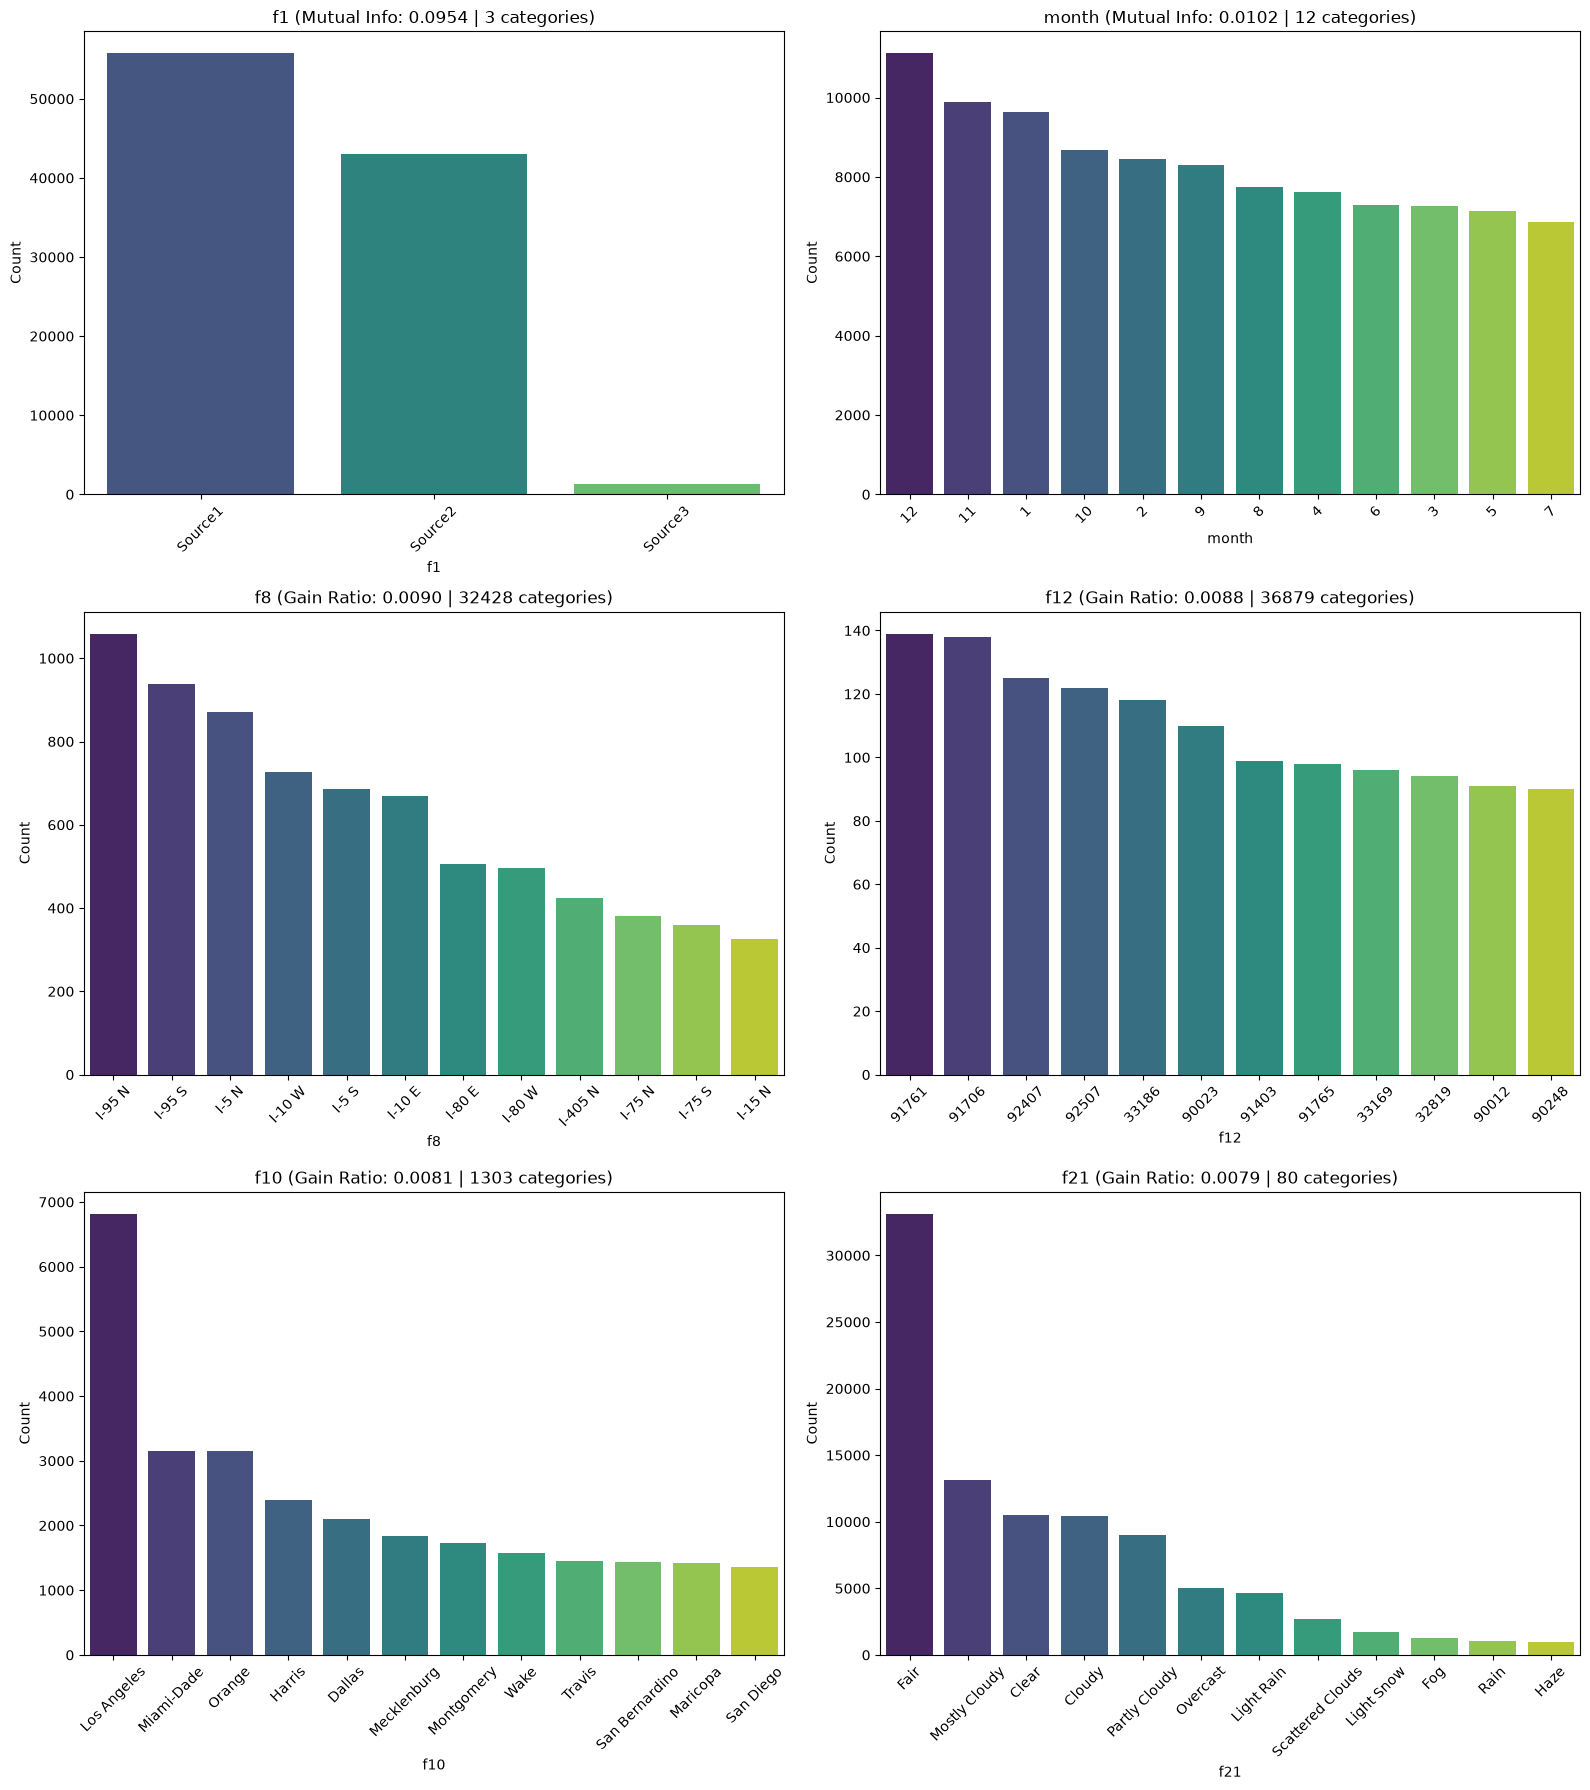

In [17]:
top_n = 6
top_features = results_df.head(top_n)['Feature'].tolist()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    row = results_df[results_df['Feature'] == feature].iloc[0]
    score = row['Score']
    method = row['Method']
    cardinality = row['Cardinality']
    
    counts = df[feature].value_counts().head(12)
    sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=axes[i])
    
    axes[i].set_title(
        f"{feature} ({method}: {score:.4f} | {cardinality} categories)",
        fontsize=12
    )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

if len(top_features) < len(axes):
    for j in range(len(top_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Mutual Information Scores (Boolean Features vs y):
f29    0.008877
f31    0.005530
f33    0.004817
f34    0.003389
f27    0.003232
f22    0.002526
f32    0.002233
f23    0.001328
f28    0.000212
f25    0.000159
f24    0.000000
f26    0.000000
f30    0.000000
dtype: float64


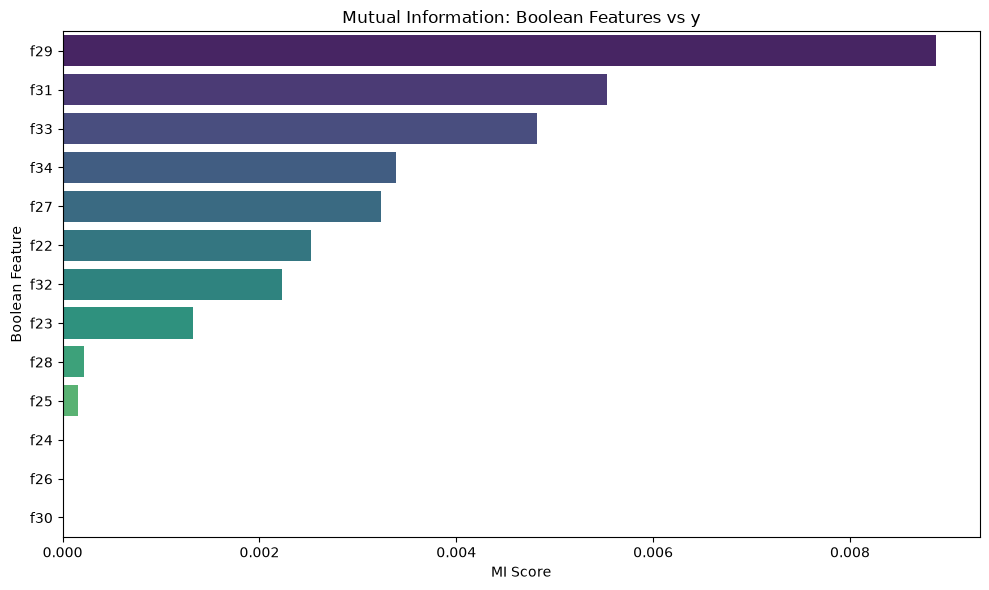

In [18]:
if 'bool_cols' in locals() and bool_cols and 'y' in df.columns:
    valid_bool_cols = [c for c in bool_cols if c in df.columns]

    df_mi = df[valid_bool_cols + ['y']].dropna()
    if df_mi['y'].nunique() >= 2 and valid_bool_cols:
        mi_scores = mutual_info_classif(df_mi[valid_bool_cols], df_mi['y'].astype(int), random_state=42)
        mi_series = pd.Series(mi_scores, index=valid_bool_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Boolean Features vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(valid_bool_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Boolean Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Boolean Feature')
        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient valid data for Mutual Information analysis.")
elif 'y' not in df.columns:
    print("Missing target column 'y'.")
else:
    print("No boolean columns found.")


In [19]:
bool_cols = ['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']

for col in bool_cols:
    if col in df.columns:
        print(f"{col}: True={df[col].sum()}, False={len(df) - df[col].sum()}, %True={df[col].mean()*100:.1f}%")

f22: True=1234, False=98766, %True=1.2%
f23: True=47, False=99953, %True=0.0%
f24: True=7315, False=92685, %True=7.3%
f25: True=886, False=99114, %True=0.9%
f26: True=3, False=99997, %True=0.0%
f27: True=2919, False=97081, %True=2.9%
f28: True=104, False=99896, %True=0.1%
f29: True=14681, False=85319, %True=14.7%
f30: True=0, False=100000, %True=0.0%
f31: True=31141, False=68859, %True=31.1%
f32: True=26432, False=73568, %True=26.4%
f33: True=21323, False=78677, %True=21.3%
f34: True=17476, False=82524, %True=17.5%


Binary columns: ['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,true_count,false_count
f22,1234,98766
f23,47,99953
f24,7315,92685
f25,886,99114
f26,3,99997
f27,2919,97081
f28,104,99896
f29,14681,85319
f30,0,100000
f31,31141,68859


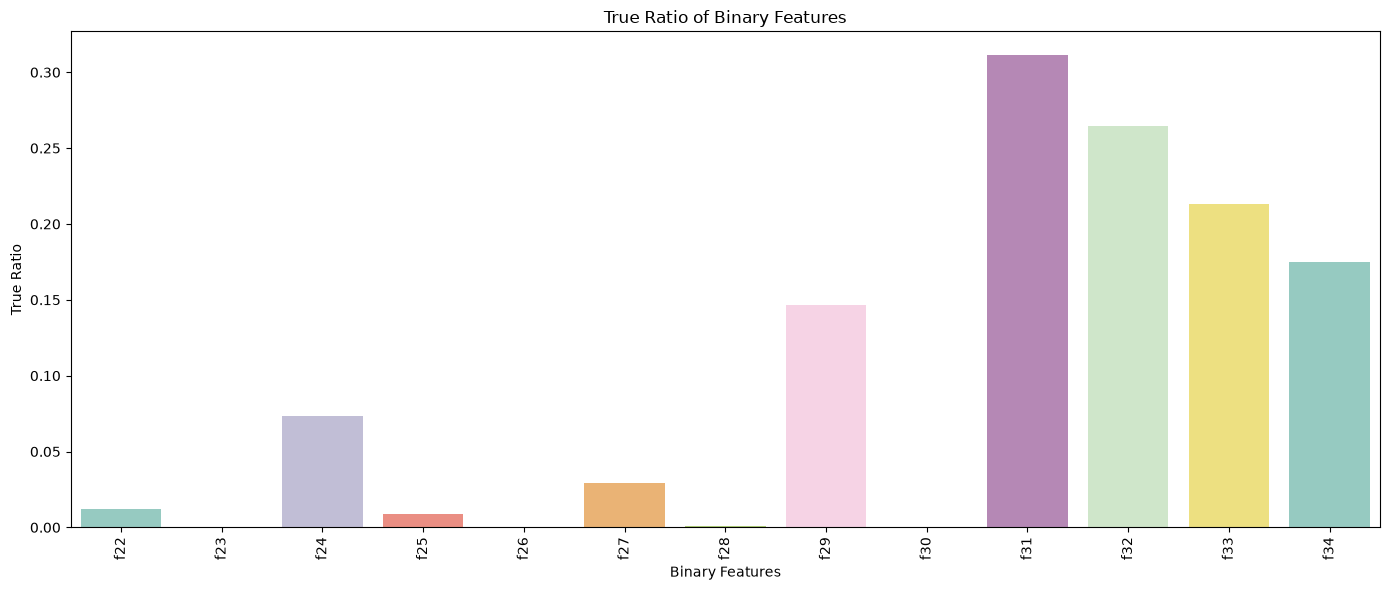

In [20]:
binary_cols = [col for col in df.columns if df[col].dropna().isin([True, False]).all()]
print('Binary columns:', binary_cols)

binary_summary = pd.DataFrame({
    'true_count': df[binary_cols].sum(numeric_only=True),
    'false_count': df[binary_cols].shape[0] - df[binary_cols].sum(numeric_only=True)
    
})
display(binary_summary)

binary_summary['true_ratio'] = binary_summary['true_count'] / (binary_summary['true_count'] + binary_summary['false_count'])
plt.figure(figsize=(14, 6))
sns.barplot(x=binary_summary.index, y=binary_summary['true_ratio'], palette='Set3')
plt.xticks(rotation=90)
plt.title('True Ratio of Binary Features')
plt.ylabel('True Ratio')
plt.xlabel('Binary Features')
plt.tight_layout()
plt.show()


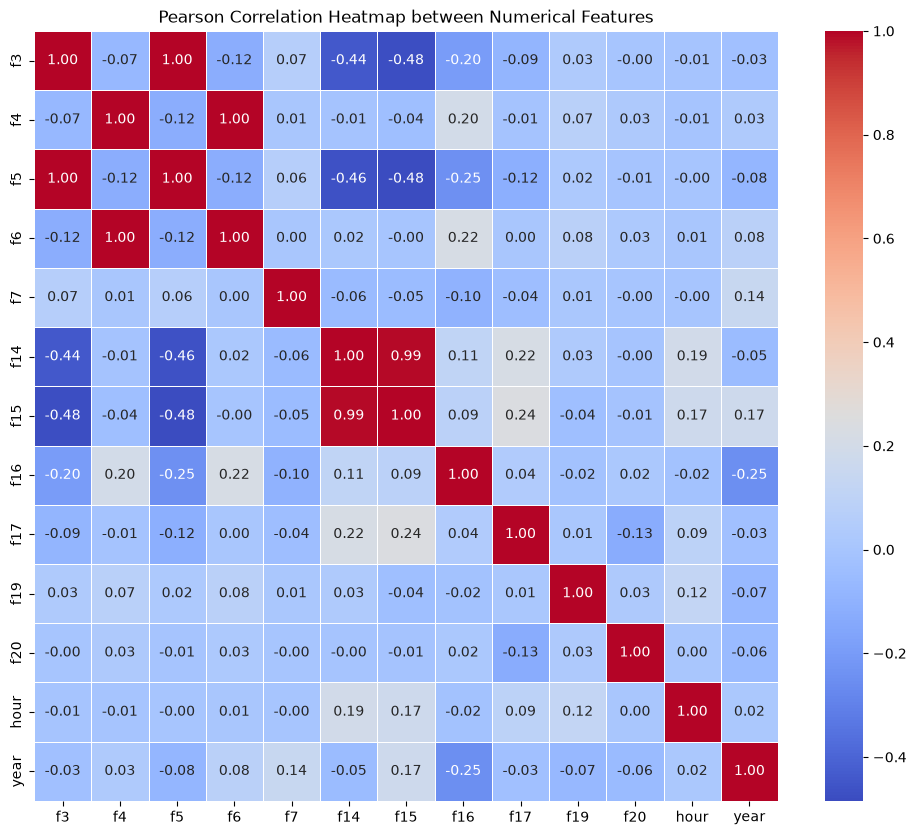

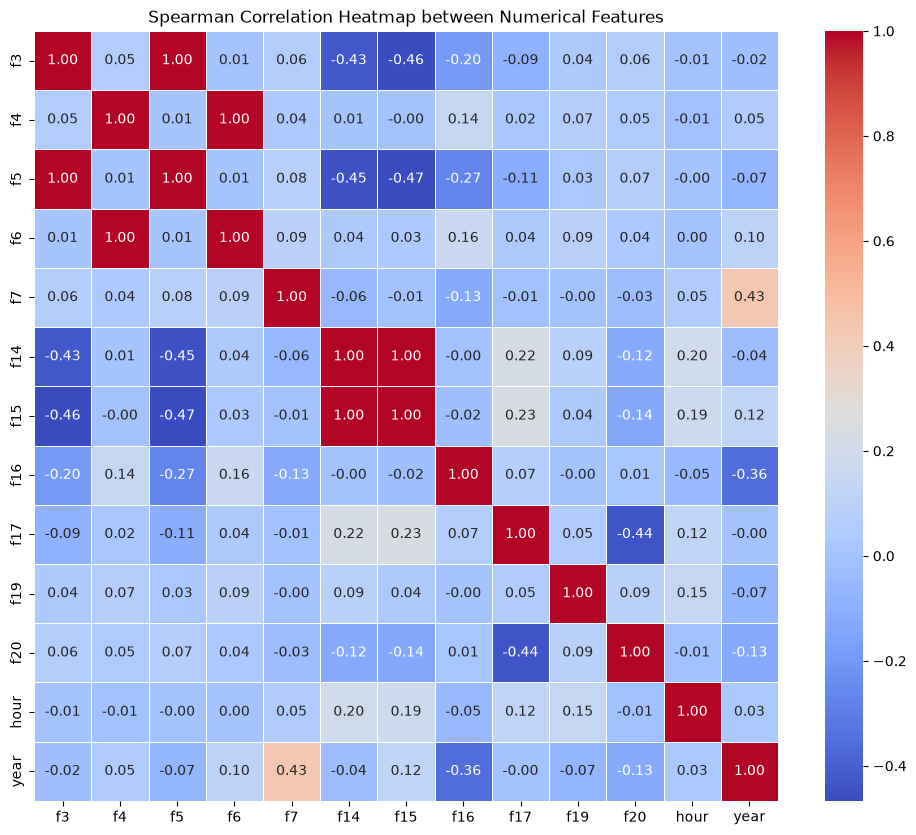

In [21]:
if numeric_cols:
    # Pearson Correlation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Heatmap between Numerical Features')
    plt.show()

    # Spearman Correl ation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Spearman Correlation Heatmap between Numerical Features')
    plt.show()
else:
    print("No numerical columns found for correlation analysis.")


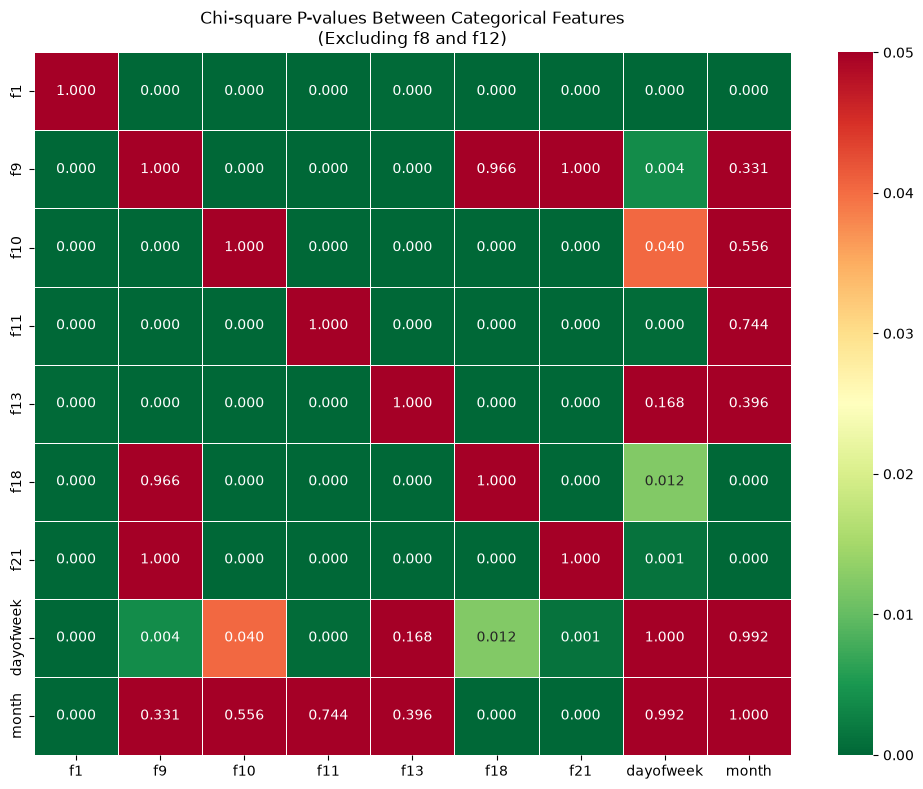


🔍 Significant relationships (p-value < 0.05):
  f9 ↔ f10: p = 0.000000
  f9 ↔ f11: p = 0.000000
  f9 ↔ f13: p = 0.000000
  f10 ↔ f11: p = 0.000000
  f10 ↔ f13: p = 0.000000
  f11 ↔ f13: p = 0.000000
  f13 ↔ f21: p = 0.000000
  f18 ↔ f21: p = 0.000000
  f11 ↔ f21: p = 0.000000
  f1 ↔ f21: p = 0.000000


In [22]:

cat_cols = [
    c for c in df.select_dtypes(include=['object', 'category']).columns
    if c not in ['f2', 'f8', 'f12'] 
]

sample_df = df.sample(min(5000, len(df)), random_state=42)

pval_matrix = pd.DataFrame(
    1.0,
    index=cat_cols,
    columns=cat_cols
)

for i, col1 in enumerate(cat_cols):
    for col2 in cat_cols[i+1:]:  
        contingency = pd.crosstab(sample_df[col1], sample_df[col2])
        
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue
            
        chi2, p_val, dof, expected = chi2_contingency(contingency)
        
        pval_matrix.loc[col1, col2] = p_val
        pval_matrix.loc[col2, col1] = p_val

plt.figure(figsize=(10, 8))

sns.heatmap(
    pval_matrix,
    annot=True,
    cmap='RdYlGn_r',  
    vmin=0,
    vmax=0.05,        
    fmt=".3f",
    linewidths=.5
)

plt.title("Chi-square P-values Between Categorical Features\n(Excluding f8 and f12)")
plt.tight_layout()
plt.show()


print("\n🔍 Significant relationships (p-value < 0.05):")
significant = []

for i, col1 in enumerate(cat_cols):
    for col2 in cat_cols[i+1:]:
        p_val = pval_matrix.loc[col1, col2]
        if p_val < 0.05:
            significant.append((col1, col2, p_val))

significant.sort(key=lambda x: x[2])

for col1, col2, p_val in significant[:10]:  
    print(f"  {col1} ↔ {col2}: p = {p_val:.6f}")

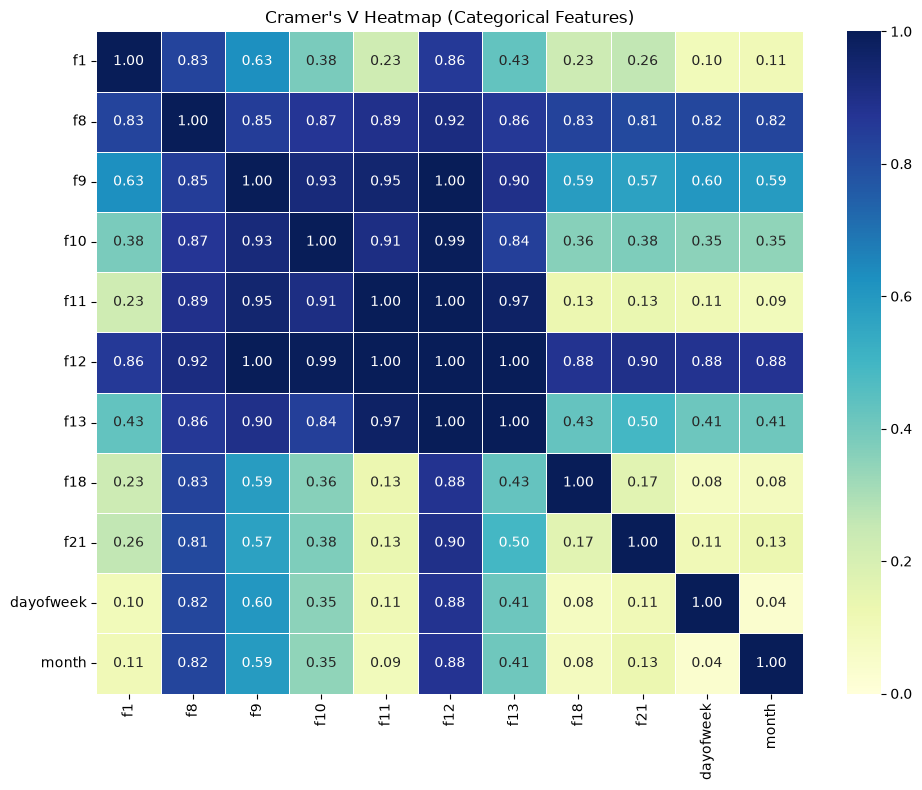

In [23]:
def cramers_v(x, y):

    confusion_matrix = pd.crosstab(x, y)

    if confusion_matrix.empty or confusion_matrix.to_numpy().sum() == 0:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape

    if min(r - 1, k - 1) <= 0:
        return 0.0

    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

cat_cols = [
    c
    for c in sample_df.select_dtypes(
        include=['object', 'category']
    ).columns
    if c != 'f2'
]


cramers_matrix = pd.DataFrame(
    np.eye(len(cat_cols)),
    index=cat_cols,
    columns=cat_cols
)


for i, col1 in enumerate(cat_cols):

    for j, col2 in enumerate(cat_cols):

        if i < j:

            val = cramers_v(
                sample_df[col1],
                sample_df[col2]
            )

            cramers_matrix.loc[col1, col2] = val
            cramers_matrix.loc[col2, col1] = val


plt.figure(figsize=(10, 8))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=.5
)

plt.title("Cramer's V Heatmap (Categorical Features)")
plt.tight_layout()
plt.show()

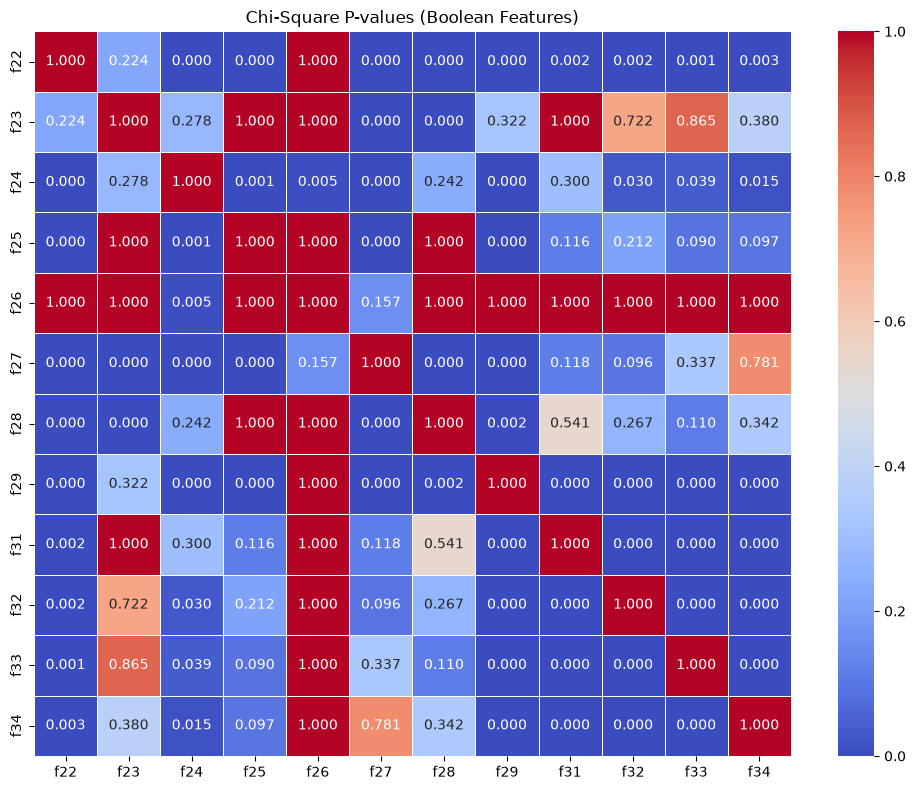

In [24]:
if 'bool_cols' in locals() and len(bool_cols) >= 2:

    valid_bool_cols = [
        c
        for c in bool_cols
        if c in df.columns and df[c].nunique(dropna=True) > 1
    ]

    if len(valid_bool_cols) >= 2:

        pval_matrix = pd.DataFrame(
            1.0,
            index=valid_bool_cols,
            columns=valid_bool_cols
        )

        for i, col1 in enumerate(valid_bool_cols):

            for col2 in valid_bool_cols[i + 1:]:

                table = pd.crosstab(df[col1], df[col2])

                if table.shape[0] > 1 and table.shape[1] > 1:

                    _, p_val, _, _ = chi2_contingency(table)

                    pval_matrix.loc[col1, col2] = p_val
                    pval_matrix.loc[col2, col1] = p_val


        plt.figure(figsize=(10, 8))

        sns.heatmap(
            pval_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=0,
            vmax=1,
            fmt=".3f",
            linewidths=.5
        )

        plt.title('Chi-Square P-values (Boolean Features)')
        plt.tight_layout()
        plt.show()

,missing_count,missing_percent
f6,44256,44.256
f5,44256,44.256
f20,28631,28.631
f15,25982,25.982
f19,7375,7.375
f18,2227,2.227
f17,2207,2.207
f21,2182,2.182
f14,2074,2.074
f16,1788,1.788


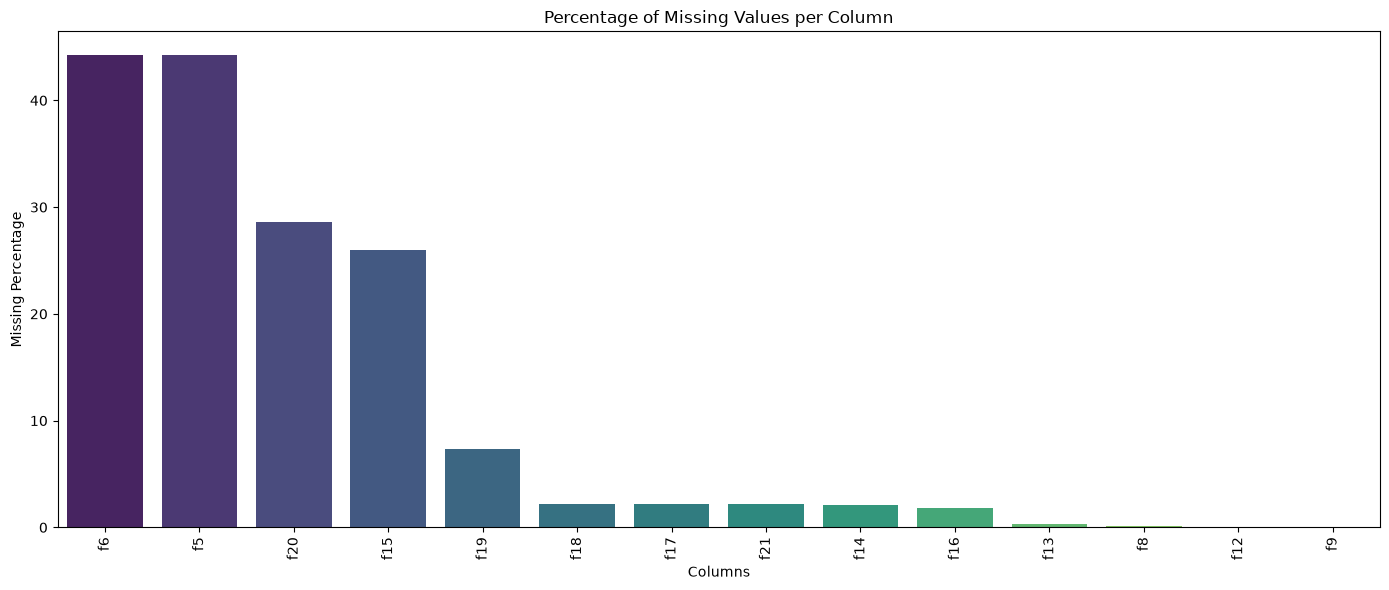

In [25]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

missing_df = missing_df[missing_df['missing_count'] > 0]

display(missing_df)

plt.figure(figsize=(14,6))
sns.barplot(x=missing_df.index, y=missing_df['missing_percent'], palette='viridis')

plt.xticks(rotation=90)
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Percentage')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()


In [26]:
outlier_counts = {}

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient="index", columns=["Outlier Count"])

outlier_df.sort_values("Outlier Count", ascending=False)


,Outlier Count
f17,19203
f7,12529
f20,6907
f16,5836
f19,2708
f14,625
f15,558
f4,0
f3,0
f6,0


In [27]:
unique_counts = df.nunique().sort_values(ascending=False)

display(unique_counts.to_frame(name='unique_values'))

,unique_values
f3,90725
f4,90686
f6,51577
f5,51573
f12,36879
f8,32428
f9,6406
f7,6177
f13,1616
f10,1303


In [28]:
near_constant = []

for col in df.columns:
    
    top_freq = df[col].value_counts(normalize=True).values[0]
    
    if top_freq > 0.95:
        near_constant.append(col)

print("Near constant features:")
print(near_constant)


Near constant features:
['f22', 'f23', 'f25', 'f26', 'f27', 'f28', 'f30']


In [29]:
original_rows = len(df)

df.drop_duplicates(inplace=True)

print("Removed rows:", original_rows - len(df))
print("New shape:", df.shape)


Removed rows: 136
New shape: (99864, 38)


In [30]:
row_threshold = 0.2

df = df.dropna(thresh=int((1 - row_threshold) * df.shape[1]))

print("Shape after removing highly-missing rows:", df.shape)



Shape after removing highly-missing rows: (99098, 38)


In [31]:
low_nan_cols = [col for col in df.columns if 0 < df[col].isnull().mean() < 0.05]

df.dropna(subset=low_nan_cols, inplace=True)

print("Shape after removing rows with small NaN columns:", df.shape)


Shape after removing rows with small NaN columns: (96417, 38)


In [32]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percent": missing_percent
})

missing_table = missing_table[missing_table["Missing Count"] > 0]

missing_table = missing_table.sort_values("Missing Percent", ascending=False)

missing_table


,Missing Count,Missing Percent
f5,43053,44.652914
f6,43053,44.652914
f20,26584,27.571901
f15,23102,23.960505
f19,4902,5.084166


In [33]:
corr_3_5 = df['f3'].corr(df['f5'])
corr_4_6 = df['f4'].corr(df['f6'])
corr_14_15 = df['f14'].corr(df['f15'])

print(f"Correlation between f3 and f5: {corr_3_5:.4f}")
print(f"Correlation between f4 and f6: {corr_4_6:.4f}")
print(f"Correlation between f14 and f15: {corr_14_15:.4f}")

df.drop(columns=['f5', 'f6', 'f15'], inplace=True)

print("\nColumns 'f5', 'f6', and 'f15' have been dropped.")
print("Current columns in dataframe:", df.columns.tolist())


Correlation between f3 and f5: 1.0000
Correlation between f4 and f6: 1.0000
Correlation between f14 and f15: 0.9938

Columns 'f5', 'f6', and 'f15' have been dropped.
Current columns in dataframe: ['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']


In [34]:
df.shape

(96417, 35)

In [35]:
cols = ['f19', 'f20']

print("Shape:", df[cols].shape)

print("\nMissing values:")
print(df[cols].isna().sum())

print("\nMissing percentage:")
print(df[cols].isna().mean() * 100)

print("\nDescriptive statistics:")
print(df[cols].describe())

print("\nCorrelation:")
print(df[cols].corr())


Shape: (96417, 2)

Missing values:
f19     4902
f20    26584
dtype: int64

Missing percentage:
f19     5.084166
f20    27.571901
dtype: float64

Descriptive statistics:
                f19           f20
count  91515.000000  69833.000000
mean       7.682247      0.007857
std        5.880811      0.087978
min        0.000000      0.000000
25%        4.600000      0.000000
50%        7.000000      0.000000
75%       10.400000      0.000000
max      812.000000      9.990000

Correlation:
          f19       f20
f19  1.000000  0.032516
f20  0.032516  1.000000


In [36]:

X = df[['f19','f20']]
y = df['y']

X = X.fillna(X.median())

mi = mutual_info_classif(X, y)

for col, score in zip(X.columns, mi):
    print(f"{col}: {score}")



f19: 0.026051120145182738
f20: 0.0


In [37]:
df['f19'] = df['f19'].fillna(df['f19'].median())

df.drop(columns=['f20'], inplace=True)

print("f19 missing values filled with median and f20 dropped.")
print("Current columns:", df.columns.tolist())


f19 missing values filled with median and f20 dropped.
Current columns: ['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']


In [38]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)


Numeric columns: 10
['f3', 'f4', 'f7', 'f14', 'f16', 'f17', 'f19', 'y', 'hour', 'year']

Categorical columns: 11
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']

Boolean columns: 13
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


In [39]:
df.head(5)

,f1,f3,f4,f7,f8,f9,f10,f11,f12,f13,f14,f16,f17,f18,f19,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,Source2,40.810566,-73.256042,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,29.77,10.0,NNW,13.8,Overcast,False,False,False,False,False,False,False,True,False,False,False,False,False,2,17,4,3,2018
1,Source1,45.358867,-122.762271,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,29.78,10.0,NNE,3.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,2,13,2,7,2022
2,Source1,41.233610,-95.954493,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,28.67,10.0,VAR,3.0,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,2,13,0,6,2022
3,Source1,34.039947,-117.505855,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,28.89,10.0,WSW,5.0,Fair,False,False,False,False,False,False,False,False,False,True,True,True,True,2,21,1,9,2021
4,Source2,47.230240,-122.448868,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,29.53,10.0,W,8.0,Cloudy,False,False,False,False,False,False,False,False,False,True,False,False,False,3,20,3,5,2019


In [40]:
near_constant_bool = ['f24', 'f25', 'f26', 'f28', 'f30', 'f23']

df = df.drop(columns=near_constant_bool)

print(f"Dropped {len(near_constant_bool)} near‑constant boolean features.")
print(f"Remaining boolean features: {df.select_dtypes(include=['bool']).columns.tolist()}")

Dropped 6 near‑constant boolean features.
Remaining boolean features: ['f22', 'f27', 'f29', 'f31', 'f32', 'f33', 'f34']


In [41]:
df.shape

(96417, 28)

In [42]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)


Numeric columns: 10
['f3', 'f4', 'f7', 'f14', 'f16', 'f17', 'f19', 'y', 'hour', 'year']

Categorical columns: 11
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']

Boolean columns: 7
['f22', 'f27', 'f29', 'f31', 'f32', 'f33', 'f34']


In [43]:
df

,f1,f3,f4,f7,f8,f9,f10,f11,f12,f13,f14,f16,f17,f18,f19,f21,f22,f27,f29,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,Source2,40.810566,-73.256042,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,29.77,10.0,NNW,13.8,Overcast,False,False,True,False,False,False,False,2,17,4,3,2018
1,Source1,45.358867,-122.762271,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,29.78,10.0,NNE,3.0,Fair,False,False,False,False,False,False,False,2,13,2,7,2022
2,Source1,41.233610,-95.954493,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,28.67,10.0,VAR,3.0,Mostly Cloudy,False,False,False,False,False,False,False,2,13,0,6,2022
3,Source1,34.039947,-117.505855,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,28.89,10.0,WSW,5.0,Fair,False,False,False,True,True,True,True,2,21,1,9,2021
4,Source2,47.230240,-122.448868,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,29.53,10.0,W,8.0,Cloudy,False,False,False,True,False,False,False,3,20,3,5,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Source2,35.911552,-78.651360,0.000,Six Forks Rd,Raleigh,Wake,NC,27615,KRDU,63.0,29.65,10.0,W,5.0,Partly Cloudy,False,False,True,False,False,False,False,3,16,1,2,2021
99996,Source2,37.770409,-122.406929,0.000,Brannan St,San Francisco,San Francisco,CA,94103-4906,KSFO,56.0,30.29,10.0,CALM,0.0,Fair,True,False,True,False,False,False,False,2,11,2,1,2022
99997,Source2,33.744514,-84.334320,0.000,GA-402 E,Atlanta,DeKalb,GA,30316,KATL,54.0,29.23,10.0,NW,10.0,Fair,False,False,False,False,False,False,False,3,19,4,4,2021
99998,Source1,34.081679,-117.731468,1.151,I-10 W,Pomona,Los Angeles,CA,91767,KPOC,45.0,28.83,1.0,WSW,7.0,Rain,False,False,False,False,False,False,False,2,14,0,12,2020


In [44]:
cat_cols = ['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes
        print(f"Encoded {col}")

print(df[cat_cols].head())

Encoded f1
Encoded f8
Encoded f9
Encoded f10
Encoded f11
Encoded f12
Encoded f13
Encoded f18
Encoded f21
Encoded dayofweek
Encoded month
   f1     f8    f9   f10  f11    f12   f13  f18  f21  dayofweek  month
0   1  15109  2381  1113   32   2050   782    9   49          4      5
1   0  19656  5614  1216   35  34561  1498    8    9          2      9
2   0  29481  4124   339   27  22432  1123   18   46          0      8
3   0   7884  1887   994    3  30533  1131   22    9          1     11
4   1  19655  5457   879   45  35777  1436   20    5          3      7


In [45]:


from sklearn.preprocessing import StandardScaler

numeric_cols = ['f3', 'f4', 'f7', 'hour', 'year']  

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Scaled columns:", numeric_cols)
print(df[numeric_cols].describe().round(3))  

Scaled columns: ['f3', 'f4', 'f7', 'hour', 'year']
              f3         f4         f7       hour       year
count  96417.000  96417.000  96417.000  96417.000  96417.000
mean      -0.000      0.000      0.000     -0.000     -0.000
std        1.000      1.000      1.000      1.000      1.000
min       -2.271     -1.710     -0.321     -2.258     -2.030
25%       -0.559     -1.292     -0.321     -0.792     -0.986
50%       -0.077      0.397     -0.307      0.124      0.058
75%        0.766      0.830     -0.058      0.857      1.102
max        2.510      1.522     64.478      1.956      1.624


In [46]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)

Numeric columns: 20
['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f21', 'hour', 'dayofweek', 'month', 'year']

Categorical columns: 0
[]

Boolean columns: 7
['f22', 'f27', 'f29', 'f31', 'f32', 'f33', 'f34']


In [47]:


outlier_counts = {}

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient="index", columns=["Outlier Count"])

outlier_df.sort_values("Outlier Count", ascending=False)


,Outlier Count
f17,18932
f7,12103
f16,5627
f19,2920
f8,642
f14,606
f1,0
f3,0
f4,0
f10,0


In [48]:
import numpy as np

test_cols = ['f17', 'f7', 'f16', 'f19', 'f14']

for col in test_cols:
    has_negative = (df[col] < 0).sum()
    has_zero = (df[col] == 0).sum()
    skewness = df[col].skew()
    
    print(f"{col}: Min={df[col].min():.2f}, Max={df[col].max():.2f}, "
          f"Negative={has_negative}, Zero={has_zero}, Skewness={skewness:.2f}")

f17: Min=0.00, Max=80.00, Negative=0, Zero=102, Skewness=1.83
f7: Min=-0.32, Max=64.48, Negative=74787, Zero=0, Skewness=13.68
f16: Min=19.75, Max=58.39, Negative=0, Zero=0, Skewness=-3.35
f19: Min=0.00, Max=812.00, Negative=0, Zero=12234, Skewness=29.26
f14: Min=-37.00, Max=122.00, Negative=227, Zero=29, Skewness=-0.50


In [49]:
import numpy as np

print("="*50)
print("Starting Capping Process")
print("="*50)
print(f"Total rows before Capping: {len(df)}\n")

cols_to_cap = ['f17', 'f7', 'f16', 'f19', 'f14']

cols_to_cap = [col for col in cols_to_cap if col in df.columns]

capping_report = {}

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    
    outliers_after = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    capping_report[col] = {
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Capped Count': outliers_before,
        'Remaining Outliers': outliers_after
    }

capping_df = pd.DataFrame.from_dict(capping_report, orient='index')
print("Capping Report:")
display(capping_df)

print(f"\nAll outliers have been successfully capped.")
print(f"Dataset size preserved. Total rows after Capping: {len(df)}")

Starting Capping Process
Total rows before Capping: 96417

Capping Report:


,Lower Bound,Upper Bound,Capped Count,Remaining Outliers
f17,10.00,10.00,18932,0
f7,-0.72,0.34,12103,0
f16,28.38,31.02,5627,0
f19,-3.50,18.10,2920,0
f14,8.50,116.50,606,0



All outliers have been successfully capped.
Dataset size preserved. Total rows after Capping: 96417


In [50]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier


X = df.drop(columns=['y'])
y = df['y']

print(f"Total features before RFE: {X.shape[1]}")


estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


selector = RFE(estimator, n_features_to_select=23, step=1)

print("Starting Recursive Feature Elimination... This may take a few minutes.")
selector = selector.fit(X, y)

selected_features = X.columns[selector.support_]
feature_ranking = pd.Series(selector.ranking_, index=X.columns).sort_values()

print("\n" + "="*50)
print(f"RFE Completed. Selected {len(selected_features)} features.")
print("="*50)

print("\nTop 25 Selected Features:")
print(selected_features.tolist())

print("\nFeature Rankings (1 is the best, higher numbers were eliminated earlier):")
print(feature_ranking.head(30))

df_selected = df[selected_features.tolist() + ['y']]

print(f"\nNew DataFrame shape with selected features: {df_selected.shape}")

Total features before RFE: 27
Starting Recursive Feature Elimination... This may take a few minutes.

RFE Completed. Selected 23 features.

Top 25 Selected Features:
['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f18', 'f19', 'f21', 'f27', 'f29', 'f31', 'f32', 'hour', 'dayofweek', 'month', 'year']

Feature Rankings (1 is the best, higher numbers were eliminated earlier):
f1           1
f3           1
f4           1
f7           1
f8           1
f9           1
f10          1
f11          1
f12          1
f13          1
f14          1
f16          1
f18          1
f19          1
f21          1
f27          1
hour         1
f29          1
f31          1
f32          1
month        1
year         1
dayofweek    1
f34          2
f33          3
f22          4
f17          5
dtype: int64

New DataFrame shape with selected features: (96417, 24)


In [51]:
cols_to_drop = ['f17', 'f22']

print(f"Shape before dropping: {df.shape}")

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns ({len(df.columns)}): {df.columns.tolist()}")

Shape before dropping: (96417, 28)
Dropped columns: ['f17', 'f22']
Shape after dropping: (96417, 26)
Remaining columns (26): ['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f18', 'f19', 'f21', 'f27', 'f29', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']


In [52]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

X = df.drop(columns=['y'])
y = df['y']

print(f"Dataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")
print(f"\nTarget percentage:\n{(y.value_counts(normalize=True).sort_index() * 100).round(2)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts().sort_index()}")
print(f"\ny_test distribution:\n{y_test.value_counts().sort_index()}")


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scoring_metric = 'f1_weighted'

print(f"\nCross-Validation: {cv.get_n_splits()} folds, Stratified")
print(f"Scoring Metric: {scoring_metric}")

Dataset shape: (96417, 25)
Target distribution:
y
1      826
2    76739
3    16337
4     2515
Name: count, dtype: int64

Target percentage:
y
1     0.86
2    79.59
3    16.94
4     2.61
Name: proportion, dtype: float64

X_train shape: (77133, 25)
X_test shape: (19284, 25)

y_train distribution:
y
1      661
2    61391
3    13069
4     2012
Name: count, dtype: int64

y_test distribution:
y
1      165
2    15348
3     3268
4      503
Name: count, dtype: int64

Cross-Validation: 5 folds, Stratified
Scoring Metric: f1_weighted


In [53]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)


dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring=scoring_metric)
print(f"Decision Tree CV F1-Weighted: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})")

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(f"\nDecision Tree Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_dt, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree CV F1-Weighted: 0.6880 (+/- 0.0079)

Decision Tree Test Results:
Accuracy: 0.6700
F1-Weighted: 0.7222
F1-Macro: 0.4718

Classification Report:
              precision    recall  f1-score   support

           1       0.19      0.88      0.31       165
           2       0.96      0.64      0.77     15348
           3       0.49      0.79      0.60      3268
           4       0.12      0.70      0.20       503

    accuracy                           0.67     19284
   macro avg       0.44      0.75      0.47     19284
weighted avg       0.85      0.67      0.72     19284



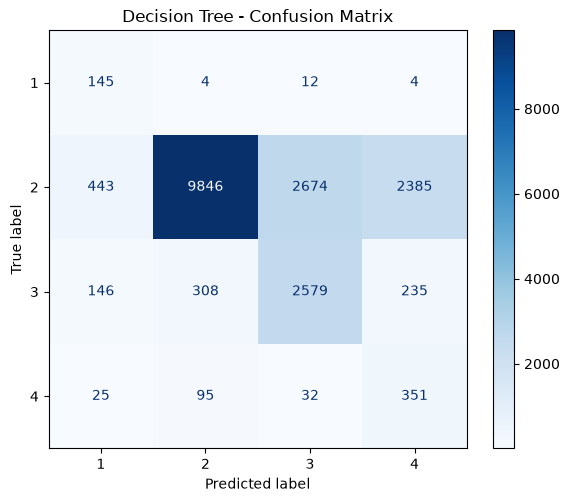


Confusion Matrix (Decision Tree):
         Predicted
         1  2  3  4
Actual 1: [145   4  12   4]
Actual 2: [ 443 9846 2674 2385]
Actual 3: [ 146  308 2579  235]
Actual 4: [ 25  95  32 351]


In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred_dt = dt_model.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Decision Tree - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (Decision Tree):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in dt_model.classes_]))
for i, row in enumerate(cm_dt):
    print(f"Actual {dt_model.classes_[i]}: {row}")

In [55]:
from sklearn.ensemble import BaggingClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, class_weight='balanced'),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

bagging_cv_scores = cross_val_score(bagging_model, X_train, y_train, cv=cv, scoring=scoring_metric)
print(f"Bagging CV F1-Weighted: {bagging_cv_scores.mean():.4f} (+/- {bagging_cv_scores.std():.4f})")

bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

print(f"\nBagging Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_bagging, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_bagging, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bagging))

Bagging CV F1-Weighted: 0.7588 (+/- 0.0031)

Bagging Test Results:
Accuracy: 0.7010
F1-Weighted: 0.7459
F1-Macro: 0.5046

Classification Report:
              precision    recall  f1-score   support

           1       0.24      0.88      0.38       165
           2       0.96      0.67      0.79     15348
           3       0.51      0.82      0.63      3268
           4       0.13      0.69      0.22       503

    accuracy                           0.70     19284
   macro avg       0.46      0.77      0.50     19284
weighted avg       0.86      0.70      0.75     19284



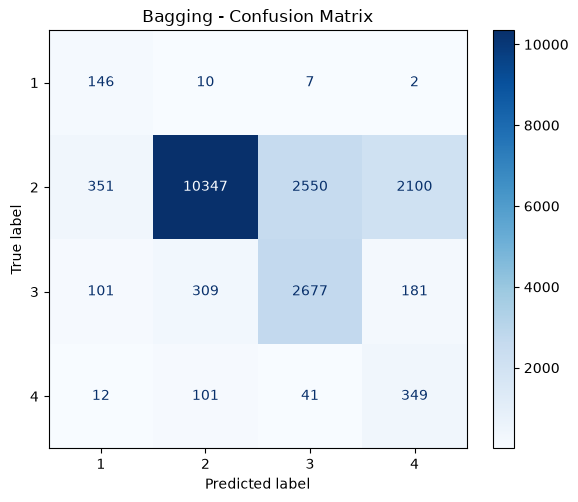


Confusion Matrix (Bagging):
         Predicted
         1  2  3  4
Actual 1: [146  10   7   2]
Actual 2: [  351 10347  2550  2100]
Actual 3: [ 101  309 2677  181]
Actual 4: [ 12 101  41 349]


In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


y_pred_bagging = bagging_model.predict(X_test)

cm_bagging = confusion_matrix(y_test, y_pred_bagging)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bagging, display_labels=bagging_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Bagging - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (Bagging):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in bagging_model.classes_]))
for i, row in enumerate(cm_bagging):
    print(f"Actual {bagging_model.classes_[i]}: {row}")



In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=21,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring=scoring_metric)
print(f"Random Forest CV F1-Weighted: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f"\nRandom Forest Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest CV F1-Weighted: 0.7883 (+/- 0.0026)

Random Forest Test Results:
Accuracy: 0.7577
F1-Weighted: 0.7898
F1-Macro: 0.5505

Classification Report:
              precision    recall  f1-score   support

           1       0.28      0.90      0.43       165
           2       0.97      0.74      0.84     15348
           3       0.53      0.83      0.65      3268
           4       0.18      0.66      0.29       503

    accuracy                           0.76     19284
   macro avg       0.49      0.79      0.55     19284
weighted avg       0.87      0.76      0.79     19284



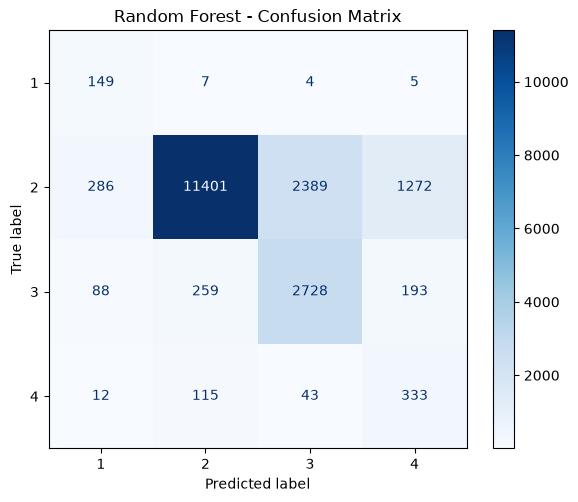


Confusion Matrix (Random Forest):
         Predicted
         1  2  3  4
Actual 1: [149   7   4   5]
Actual 2: [  286 11401  2389  1272]
Actual 3: [  88  259 2728  193]
Actual 4: [ 12 115  43 333]


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_rf = rf_model.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (Random Forest):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in rf_model.classes_]))
for i, row in enumerate(cm_rf):
    print(f"Actual {rf_model.classes_[i]}: {row}")

## Distance Based Models need standardization 

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',  
    n_jobs=-1  
)

knn_cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=cv, scoring=scoring_metric)
print(f"KNN CV F1-Weighted: {knn_cv_scores.mean():.4f} (+/- {knn_cv_scores.std():.4f})")

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print(f"\nKNN Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_knn, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN CV F1-Weighted: 0.7903 (+/- 0.0018)

KNN Test Results:
Accuracy: 0.8116
F1-Weighted: 0.7935
F1-Macro: 0.4048

Classification Report:
              precision    recall  f1-score   support

           1       0.56      0.11      0.18       165
           2       0.86      0.92      0.89     15348
           3       0.55      0.45      0.50      3268
           4       0.23      0.03      0.05       503

    accuracy                           0.81     19284
   macro avg       0.55      0.38      0.40     19284
weighted avg       0.79      0.81      0.79     19284



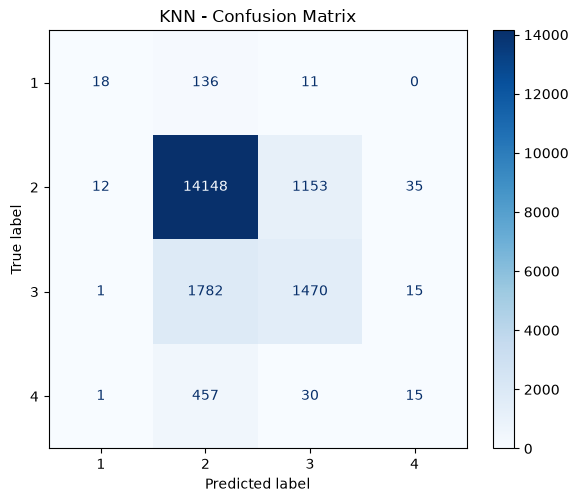


Confusion Matrix (KNN):
         Predicted
         1  2  3  4
Actual 1: [ 18 136  11   0]
Actual 2: [   12 14148  1153    35]
Actual 3: [   1 1782 1470   15]
Actual 4: [  1 457  30  15]


In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('KNN - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (KNN):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in knn_model.classes_]))
for i, row in enumerate(cm_knn):
    print(f"Actual {knn_model.classes_[i]}: {row}")

In [61]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring=scoring_metric)
print(f"Logistic Regression CV F1-Weighted: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print(f"\nLogistic Regression Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression CV F1-Weighted: 0.4623 (+/- 0.0033)

Logistic Regression Test Results:
Accuracy: 0.3984
F1-Weighted: 0.4633
F1-Macro: 0.2976

Classification Report:
              precision    recall  f1-score   support

           1       0.04      0.76      0.08       165
           2       0.93      0.31      0.47     15348
           3       0.40      0.74      0.52      3268
           4       0.07      0.70      0.13       503

    accuracy                           0.40     19284
   macro avg       0.36      0.63      0.30     19284
weighted avg       0.81      0.40      0.46     19284



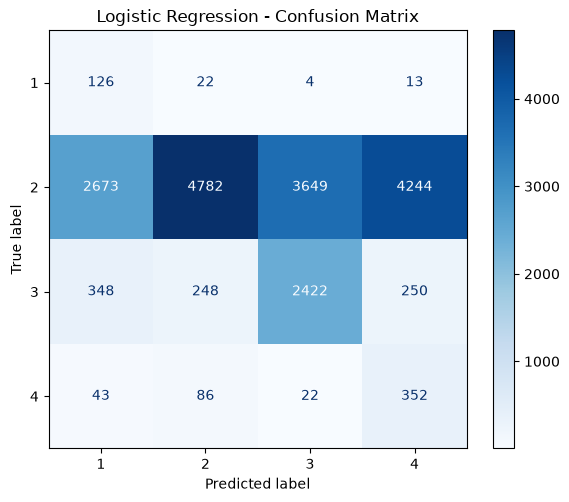


Confusion Matrix (Logistic Regression):
         Predicted
         1  2  3  4
Actual 1: [126  22   4  13]
Actual 2: [2673 4782 3649 4244]
Actual 3: [ 348  248 2422  250]
Actual 4: [ 43  86  22 352]


In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (Logistic Regression):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in lr_model.classes_]))
for i, row in enumerate(cm_lr):
    print(f"Actual {lr_model.classes_[i]}: {row}")

In [63]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    class_weight='balanced',  
    random_state=42
)

svm_cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring=scoring_metric)
print(f"SVM (Linear) CV F1-Weighted: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std():.4f})")

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)


print(f"\nSVM (Linear) Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM (Linear) CV F1-Weighted: 0.7689 (+/- 0.0025)

SVM (Linear) Test Results:
Accuracy: 0.7558
F1-Weighted: 0.7712
F1-Macro: 0.4413

Classification Report:
              precision    recall  f1-score   support

           1       0.11      0.32      0.17       165
           2       0.90      0.80      0.85     15348
           3       0.45      0.66      0.54      3268
           4       0.24      0.20      0.22       503

    accuracy                           0.76     19284
   macro avg       0.43      0.49      0.44     19284
weighted avg       0.80      0.76      0.77     19284



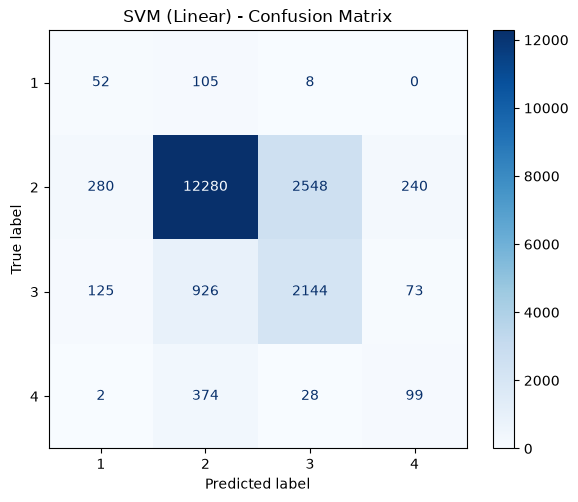


Confusion Matrix (SVM Linear):
         Predicted
         1  2  3  4
Actual 1: [ 52 105   8   0]
Actual 2: [  280 12280  2548   240]
Actual 3: [ 125  926 2144   73]
Actual 4: [  2 374  28  99]


In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('SVM (Linear) - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (SVM Linear):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in svm_model.classes_]))
for i, row in enumerate(cm_svm):
    print(f"Actual {svm_model.classes_[i]}: {row}")

In [67]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_cv_scores = cross_val_score(ada_model, X_train, y_train, cv=cv, scoring=scoring_metric)
print(f"AdaBoost CV F1-Weighted: {ada_cv_scores.mean():.4f} (+/- {ada_cv_scores.std():.4f})")

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print(f"\nAdaBoost Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_ada, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_ada, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

AdaBoost CV F1-Weighted: 0.6637 (+/- 0.0019)

AdaBoost Test Results:
Accuracy: 0.6040
F1-Weighted: 0.6676
F1-Macro: 0.3899

Classification Report:
              precision    recall  f1-score   support

           1       0.07      0.93      0.14       165
           2       0.96      0.59      0.73     15348
           3       0.36      0.67      0.47      3268
           4       0.15      0.47      0.22       503

    accuracy                           0.60     19284
   macro avg       0.38      0.67      0.39     19284
weighted avg       0.83      0.60      0.67     19284



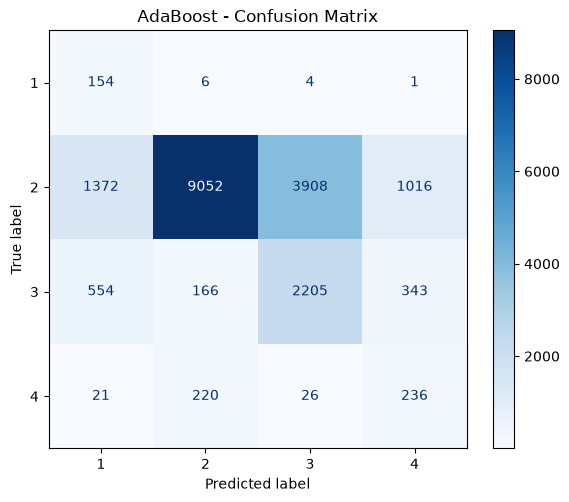


Confusion Matrix (AdaBoost):
         Predicted
         1  2  3  4
Actual 1: [154   6   4   1]
Actual 2: [1372 9052 3908 1016]
Actual 3: [ 554  166 2205  343]
Actual 4: [ 21 220  26 236]


In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns



cm_ada = confusion_matrix(y_test, y_pred_ada)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=ada_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('AdaBoost - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (AdaBoost):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in ada_model.classes_]))
for i, row in enumerate(cm_ada):
    print(f"Actual {ada_model.classes_[i]}: {row}")

In [68]:
from sklearn.ensemble import GradientBoostingClassifier


gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=cv, scoring=scoring_metric)
print(f"Gradient Boosting CV F1-Weighted: {gb_cv_scores.mean():.4f} (+/- {gb_cv_scores.std():.4f})")

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print(f"\nGradient Boosting Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"F1-Weighted: {f1_score(y_test, y_pred_gb, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, y_pred_gb, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting CV F1-Weighted: 0.8665 (+/- 0.0014)

Gradient Boosting Test Results:
Accuracy: 0.8818
F1-Weighted: 0.8709
F1-Macro: 0.6143

Classification Report:
              precision    recall  f1-score   support

           1       0.70      0.46      0.55       165
           2       0.90      0.96      0.93     15348
           3       0.79      0.62      0.70      3268
           4       0.63      0.17      0.27       503

    accuracy                           0.88     19284
   macro avg       0.75      0.56      0.61     19284
weighted avg       0.87      0.88      0.87     19284



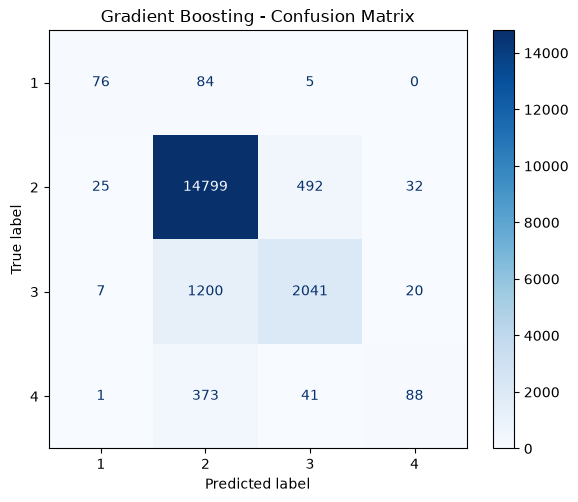


Confusion Matrix (Gradient Boosting):
         Predicted
         1  2  3  4
Actual 1: [76 84  5  0]
Actual 2: [   25 14799   492    32]
Actual 3: [   7 1200 2041   20]
Actual 4: [  1 373  41  88]


In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


cm_gb = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=gb_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Gradient Boosting - Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (Gradient Boosting):")
print("         Predicted")
print("         " + "  ".join([str(c) for c in gb_model.classes_]))
for i, row in enumerate(cm_gb):
    print(f"Actual {gb_model.classes_[i]}: {row}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

models = [
    ('Decision Tree', y_pred_dt, dt_model),
    ('KNN', y_pred_knn, knn_model),
    ('SVM (Linear)', y_pred_svm, svm_model),
    ('Logistic Regression', y_pred_lr, lr_model),
    ('Bagging', y_pred_bagging, bagging_model),
    ('Random Forest', y_pred_rf, rf_model),
    ('Gradient Boosting', y_pred_gb, gb_model),
    ('AdaBoost', y_pred_ada, ada_model)
]

for idx, (name, y_pred, model) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d', ax=axes[idx])
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices - All Models Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CONFUSION MATRICES - ALL MODELS")
print("="*80)

for name, y_pred, model in models:
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name}:")
    print("         Predicted")
    print("         " + "  ".join([str(c) for c in model.classes_]))
    for i, row in enumerate(cm):
        print(f"Actual {model.classes_[i]}: {row}")
    print("-"*50)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, loguniform
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)

# فرض بر این است که df بعد از preprocessing آماده است
X = df.drop(columns=['y']).copy()
y = df['y'].copy()

# اطمینان از عددی بودن y
if y.dtype == object or str(y.dtype) == 'category':
    y = y.astype('category').cat.codes
else:
    y = y.astype(int)

# ============================================
# مرحله ۱: جدا کردن Test (۱۵٪)
# ============================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# ============================================
# مرحله ۲: از ۸۵٪ باقی‌مانده، Train و Validation جدا می‌شوند
# 15/85 ≈ 0.1765 → حدود ۱۵٪ کل داده
# ============================================
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

y_train = np.asarray(y_train)
y_val = np.asarray(y_val)
y_test = np.asarray(y_test)

# ============================================
# Scaling (فقط روی Train فیت می‌شود)
# ============================================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# تبدیل به numpy برای مدل‌های درختی (raw)
X_train_raw = np.asarray(X_train)
X_val_raw = np.asarray(X_val)
X_test_raw = np.asarray(X_test)

# ============================================
# PredefinedSplit برای تیونینگ با Validation جدا
# ============================================
test_fold = np.concatenate([
    np.full(len(y_train), -1, dtype=int),   # Train
    np.zeros(len(y_val), dtype=int)         # Validation
])
ps = PredefinedSplit(test_fold)

# ترکیب Train + Val برای fit
X_fit_s = np.vstack([X_train_s, X_val_s])
X_fit_raw = np.vstack([X_train_raw, X_val_raw])
y_fit = np.concatenate([y_train, y_val])

print(f"Train:      {X_train.shape[0]:,} rows")
print(f"Validation: {X_val.shape[0]:,} rows")
print(f"Test:       {X_test.shape[0]:,} rows")
print(f"Total:      {X.shape[0]:,} rows")

# دیکشنری برای ذخیره نتایج
tuning_results = []
tuned_searches = {}

In [ ]:
def tune_one_model(name, model, param_dist, use_scaled=True, n_iter=15):
    """یک مدل را تیون می‌کند و روی Val و Test ارزیابی می‌کند."""
    print(f"⚙️  Tuning {name} ...")

    X_f = X_fit_s if use_scaled else X_fit_raw
    X_v = X_val_s if use_scaled else X_val_raw
    X_t = X_test_s if use_scaled else X_test_raw

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=ps,
        scoring='f1_weighted',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_f, y_fit)

    val_pred = search.predict(X_v)
    test_pred = search.predict(X_t)

    result = {
        'Model': name,
        'Val F1-W': f1_score(y_val, val_pred, average='weighted'),
        'Val F1-M': f1_score(y_val, val_pred, average='macro'),
        'Test F1-W': f1_score(y_test, test_pred, average='weighted'),
        'Test F1-M': f1_score(y_test, test_pred, average='macro'),
        'Test Acc': accuracy_score(y_test, test_pred),
        'Best Params': search.best_params_
    }

    tuning_results.append(result)
    tuned_searches[name] = search

    print(f"✅ {name} done | Val F1-W: {result['Val F1-W']:.4f} | Test F1-W: {result['Test F1-W']:.4f}")
    print(f"   Best Params: {search.best_params_}\n")
    return search, result


# فضای پارامترها برای همه مدل‌ها
dt_param = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [5, 10, 20, 50],
    'min_samples_leaf': [2, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

bagging_param = {
    'n_estimators': [50, 100, 150],
    'max_samples': [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0],
    'estimator__max_depth': [5, 10, 15, 20, None],
    'estimator__min_samples_split': [5, 20, 50],
    'estimator__min_samples_leaf': [2, 10],
    'estimator__class_weight': ['balanced', None]
}

rf_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [5, 10, 20, 50],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight': ['balanced', 'balanced_subsample']
}

knn_param = {
    'n_neighbors': randint(3, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'leaf_size': randint(20, 80)
}

lr_param = {
    'C': loguniform(1e-3, 1e3),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000, 5000],
    'class_weight': ['balanced', None]
}

svm_param = {
    'C': loguniform(1e-3, 1e3),
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [5000, 10000, 20000],
    'class_weight': ['balanced', None]
}

ada_param = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3, 5],
    'estimator__class_weight': ['balanced', None]
}

gb_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [5, 10, 20]
}

print("✅ All param grids defined. Ready to tune!")

In [ ]:
dt_search, dt_res = tune_one_model(
    name='Decision Tree',
    model=DecisionTreeClassifier(random_state=42),
    param_dist=dt_param,
    use_scaled=False,
    n_iter=20
)

In [ ]:
bagging_search, bagging_res = tune_one_model(
    name='Bagging',
    model=BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42, n_jobs=-1
    ),
    param_dist=bagging_param,
    use_scaled=False,
    n_iter=15
)

In [ ]:
rf_search, rf_res = tune_one_model(
    name='Random Forest',
    model=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist=rf_param,
    use_scaled=False,
    n_iter=20
)

In [ ]:
knn_search, knn_res = tune_one_model(
    name='KNN',
    model=KNeighborsClassifier(n_jobs=-1),
    param_dist=knn_param,
    use_scaled=True,
    n_iter=20
)

In [ ]:
lr_search, lr_res = tune_one_model(
    name='Logistic Regression',
    model=LogisticRegression(random_state=42, n_jobs=-1),
    param_dist=lr_param,
    use_scaled=True,
    n_iter=20
)

In [ ]:
svm_search, svm_res = tune_one_model(
    name='SVM Linear',
    model=LinearSVC(random_state=42),
    param_dist=svm_param,
    use_scaled=True,
    n_iter=15
)

In [ ]:
ada_search, ada_res = tune_one_model(
    name='AdaBoost',
    model=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    param_dist=ada_param,
    use_scaled=False,
    n_iter=15
)

In [ ]:
gb_search, gb_res = tune_one_model(
    name='Gradient Boosting',
    model=GradientBoostingClassifier(random_state=42),
    param_dist=gb_param,
    use_scaled=False,
    n_iter=15
)

In [ ]:
# ساخت DataFrame از همه نتایج
results_df = pd.DataFrame(tuning_results)
results_df = results_df.sort_values('Val F1-W', ascending=False).reset_index(drop=True)

# نمایش جدول مقایسه
display_cols = ['Model', 'Val F1-W', 'Val F1-M', 'Test F1-W', 'Test F1-M', 'Test Acc']

print("=" * 90)
print("🏆 FINAL COMPARISON - SORTED BY VALIDATION F1-WEIGHTED")
print("=" * 90)

try:
    styled = results_df[display_cols].style.highlight_max(
        subset=['Val F1-W', 'Val F1-M', 'Test F1-W', 'Test F1-M', 'Test Acc'],
        color='lightgreen'
    )
    display(styled)
except:
    print(results_df[display_cols])

# بهترین مدل
best_name = results_df.iloc[0]['Model']
best_search = tuned_searches[best_name]

print("\n" + "=" * 90)
print(f"🥇 BEST MODEL (based on Validation F1): {best_name}")
print("=" * 90)
print(f"Validation F1-Weighted: {results_df.iloc[0]['Val F1-W']:.4f}")
print(f"Test F1-Weighted:       {results_df.iloc[0]['Test F1-W']:.4f}")
print(f"Test Accuracy:          {results_df.iloc[0]['Test Acc']:.4f}")
print(f"Best Parameters:        {best_search.best_params_}")

In [ ]:
# مدل‌هایی که نیاز به scaled دارند
scaled_models = {'KNN', 'Logistic Regression', 'SVM Linear'}

if best_name in scaled_models:
    X_test_best = X_test_s
else:
    X_test_best = X_test_raw

y_pred_best = best_search.predict(X_test_best)

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_search.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title(f'Best Model: {best_name} - Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\n📊 Classification Report for {best_name}:")
print(classification_report(y_test, y_pred_best))